In [1]:
import duckdb
import pandas as pd

print("🦆 Extraindo Logs de Interação (Direto do arquivo base)...")
pasta_dados = "export/" 

# Busca simplificada, apenas no arquivo de logs
query_logs = f"""
    SELECT timecreated, username, eventname, action, 
           component, contextinstanceid, courseid
    FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE)
    WHERE username NOT IN ('0', '-1', '', 'nan') AND username IS NOT NULL
    ORDER BY CAST(timecreated AS BIGINT) ASC
"""
df_logs = duckdb.query(query_logs).df()

# Criamos a coluna 'section' artificialmente com valor nulo para não quebrar o transformador
df_logs['section'] = 'nan'

def analisar_dataset_moodle(df):
    print("📊 --- RADIOGRAFIA DO DATASET DO MOODLE --- 📊\n")
    
    # 1. Total de Eventos (Linhas de Log)
    total_eventos = len(df)
    print(f"🔹 Total de Interações (Logs): {total_eventos:,}".replace(',', '.'))
    
    # 2. Total de Alunos Únicos
    # Filtra possíveis usuários nulos ou do sistema ('0', '-1')
    alunos_validos = df[~df['username'].isin(['0', '-1', 'nan', 'None', ''])]
    total_alunos = alunos_validos['username'].nunique()
    print(f"👨‍🎓 Total de Alunos Únicos: {total_alunos:,}".replace(',', '.'))
    
    # 3. Total de Matérias (Courses)
    materias_validas = df[~df['courseid'].isin(['0', 'nan', 'None', ''])]
    total_materias = materias_validas['courseid'].nunique()
    print(f"📚 Total de Matérias (Cursos): {total_materias:,}".replace(',', '.'))
    
    # 4. Total de Seções
    secoes_validas = df[~df['section'].isin(['0', 'nan', 'None', ''])]
    total_secoes = secoes_validas['section'].nunique()
    print(f"🗂️ Total de Seções: {total_secoes:,}".replace(',', '.'))
    
    # 5. Total de Atividades Únicas (Context Instances)
    atividades_validas = df[~df['contextinstanceid'].isin(['0', 'nan', 'None', ''])]
    total_atividades = atividades_validas['contextinstanceid'].nunique()
    print(f"📝 Total de Atividades: {total_atividades:,}".replace(',', '.'))
    
    print("\n🏆 --- TOP 5 EVENTOS MAIS COMUNS (O que os alunos mais fazem?) --- 🏆")
    top_eventos = df['eventname'].value_counts().head(5)
    for evento, qtd in top_eventos.items():
        print(f"   - {evento}: {qtd:,}".replace(',', '.'))
        
    print("\n🧩 --- TOP 5 COMPONENTES (Onde eles mais clicam?) --- 🧩")
    top_componentes = df['component'].value_counts().head(5)
    for comp, qtd in top_componentes.items():
        print(f"   - {comp.replace('mod_', '')}: {qtd:,}".replace(',', '.'))

# AQUI ESTÁ A CORREÇÃO: Passando a variável df_logs correta!
analisar_dataset_moodle(df_logs)

🦆 Extraindo Logs de Interação (Direto do arquivo base)...
📊 --- RADIOGRAFIA DO DATASET DO MOODLE --- 📊

🔹 Total de Interações (Logs): 2.391.762
👨‍🎓 Total de Alunos Únicos: 2.168
📚 Total de Matérias (Cursos): 5.202
🗂️ Total de Seções: 0
📝 Total de Atividades: 17.707

🏆 --- TOP 5 EVENTOS MAIS COMUNS (O que os alunos mais fazem?) --- 🏆
   - \core\event\message_sent: 544.059
   - \core\event\webservice_function_called: 257.108
   - \core\event\course_viewed: 251.592
   - \mod_forum\event\discussion_viewed: 152.132
   - \core\event\message_viewed: 150.878

🧩 --- TOP 5 COMPONENTES (Onde eles mais clicam?) --- 🧩
   - core: 1.675.033
   - forum: 322.043
   - book: 119.033
   - quiz: 66.706
   - page: 45.813


In [2]:
import duckdb

query_cursos_reais = fquery_logs = f"""
        SELECT logs.timecreated, logs.username, logs.eventname, logs.action, 
            logs.component, logs.contextinstanceid, logs.courseid, cm.section AS section
    FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE) AS logs
    LEFT JOIN read_csv_auto('{pasta_dados}mdl_course_modules.csv', ALL_VARCHAR=TRUE) AS cm
        ON logs.contextinstanceid = cm.id
    WHERE logs.username NOT IN ('0', '-1', '', 'nan') AND logs.username IS NOT NULL
    AND courseid IN ('10464')
    ORDER BY CAST(logs.timecreated AS BIGINT) ASC
"""
df_cursos = duckdb.query(query_cursos_reais).df()

(df_cursos).to_csv("cursos_reais.csv", index=False)

In [3]:
quantas_complecoes = f"""
    SELECT 
        COUNT(DISTINCT logs.id) as qtd_complecoes
    FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE) AS logs
    WHERE logs.username NOT IN ('0', '-1', '', 'nan') 
      AND logs.username = 'user7219802108604710913'
      AND logs.courseid = '10464'
      AND logs.eventname = '\\mod_quiz\\event\\attempt_submitted'
      AND logs.contextinstanceid = '54994'
    GROUP BY logs.courseid
"""

df_cursos = duckdb.query(quantas_complecoes).df()
display(df_cursos)

,qtd_complecoes
0,10


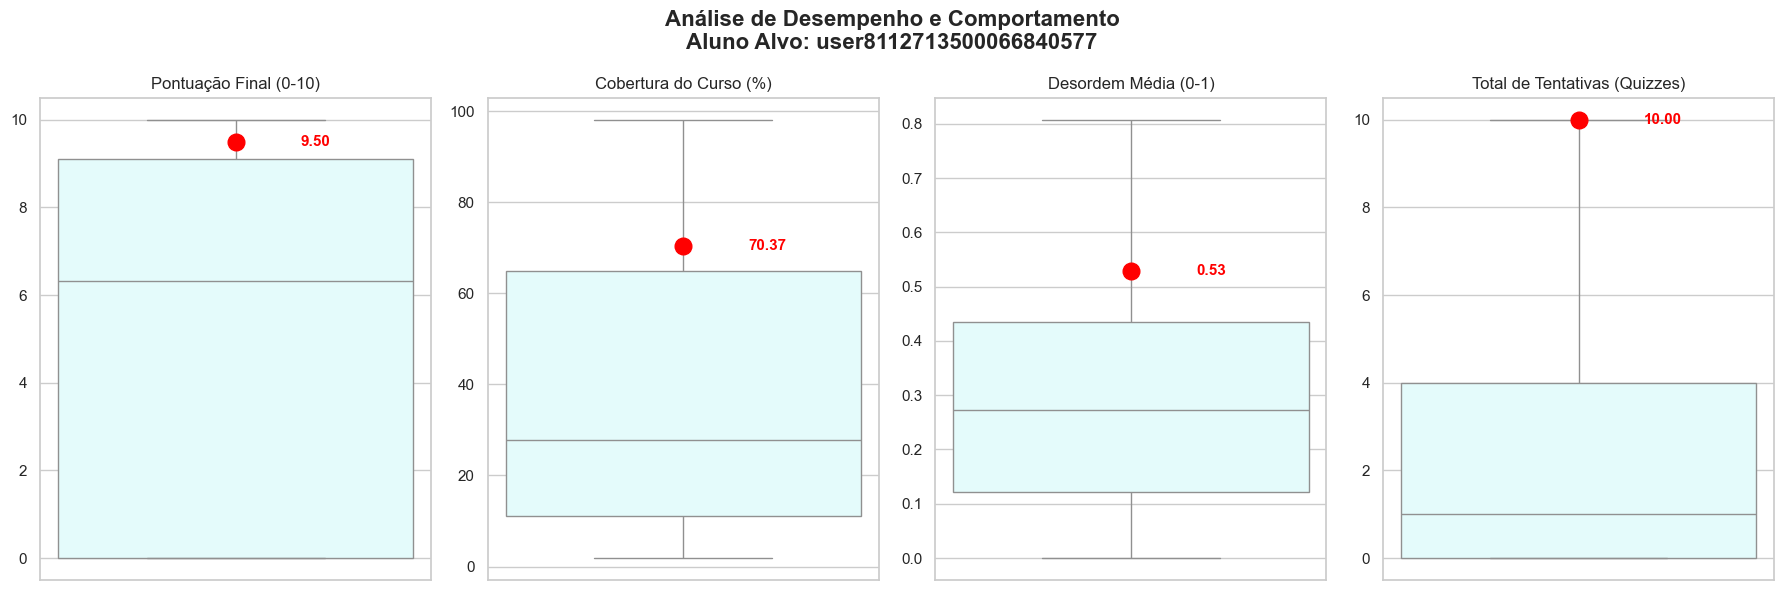


--- Tabela de Valores do Aluno Alvo ---


,usuario,pontuacao,porcentagem_acessada,desordem_media,total_tentativas
1827,user8112713500066840577,9.5,70.37,0.52942,10.0


In [6]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

# Carrega as variáveis de ambiente
load_dotenv(override=True)

# Puxa o caminho da pasta de dados do arquivo .env
export_path = os.getenv("PASTA_DADOS")

# Definição dinâmica dos caminhos
atividades_path = os.path.join(export_path, "atividades.json")
nivel_desordem_path = os.path.join(export_path, "nivel_desordem.json")
visualizacoes_por_objeto_path = os.path.join(export_path, "visualizacoes_por_objeto.json")
proporcao_visualizacoes_path = os.path.join(export_path, "proporcao_visualizacoes_por_atividade.json")
pontuacao_path = os.path.join(export_path, "pontuacao.json")
porcentagem_curso_path = os.path.join(export_path, "porcentagem_curso_acessada.json")
tentativas_por_questionario_path = os.path.join(export_path, "tentativas_por_questionario.json")
tempo_resposta_path = os.path.join(export_path, "tempo_resposta.json")
tempo_total_gasto_em_visitas_reais_path = os.path.join(export_path, "tempo_total_gasto_em_visitas_reais.json")

# Configuração visual do gráfico
sns.set_theme(style="whitegrid")

def gerar_boxplot_aluno(aluno_alvo):
    # ==========================================
    # 1. CARREGAMENTO E EXTRAÇÃO DAS MÉTRICAS
    # ==========================================
    
    # 1.1 Pontuação
    with open(pontuacao_path, 'r', encoding='utf-8') as f:
        pont_data = json.load(f)
    df_pont = pd.DataFrame(pont_data)[['usuario', 'pontuacao']]
    
    # 1.2 Porcentagem do Curso Acessada
    with open(porcentagem_curso_path, 'r', encoding='utf-8') as f:
        perc_data = json.load(f)
    records_perc = []
    for user, data in perc_data.get('Course 10464', {}).items():
        records_perc.append({'usuario': user, 'porcentagem_acessada': data.get('geral', 0)})
    df_perc = pd.DataFrame(records_perc)
    
    # 1.3 Nível de Desordem (Calculando a média das sessões do aluno)
    with open(nivel_desordem_path, 'r', encoding='utf-8') as f:
        desordem_data = json.load(f)
    desordem_records = {}
    for sessao, s_data in desordem_data.get('Course 10464', {}).get('sessoes', {}).items():
        usuarios = s_data.get('nivel_desordem_por_usuario', {})
        for u, val in usuarios.items():
            desordem_records.setdefault(u, []).append(val)
    df_desordem = pd.DataFrame([
        {'usuario': u, 'desordem_media': sum(vals)/len(vals)} 
        for u, vals in desordem_records.items()
    ])
    
    # 1.4 Tentativas por Questionário (Somando o total do aluno)
    with open(tentativas_por_questionario_path, 'r', encoding='utf-8') as f:
        tentativas_data = json.load(f)
    df_tentativas = pd.DataFrame(tentativas_data)
    df_tentativas = df_tentativas.groupby('usuario')['total_tentativas'].sum().reset_index()

    # ==========================================
    # 2. MERGE (UNINDO TODAS AS MÉTRICAS)
    # ==========================================
    df_final = df_pont.merge(df_perc, on='usuario', how='outer')\
                      .merge(df_desordem, on='usuario', how='outer')\
                      .merge(df_tentativas, on='usuario', how='outer')
    
    # Preenche com 0 caso o aluno não tenha registro em alguma métrica
    df_final = df_final.fillna(0)

    # ==========================================
    # 3. GERAÇÃO DOS BOX PLOTS
    # ==========================================
    metricas = ['pontuacao', 'porcentagem_acessada', 'desordem_media', 'total_tentativas']
    titulos = ['Pontuação Final (0-10)', 'Cobertura do Curso (%)', 'Desordem Média (0-1)', 'Total de Tentativas (Quizzes)']
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 6))
    fig.suptitle(f"Análise de Desempenho e Comportamento\nAluno Alvo: {aluno_alvo}", fontsize=16, fontweight='bold')
    
    # Verifica se o aluno existe na base
    aluno_existe = aluno_alvo in df_final['usuario'].values
    
    for i, metrica in enumerate(metricas):
        # Cria o Box Plot da turma inteira
        sns.boxplot(y=df_final[metrica], ax=axes[i], color='lightcyan', width=0.4, showfliers=False)
        
        axes[i].set_title(titulos[i], fontsize=12)
        axes[i].set_ylabel("")
        
        # Destaca o aluno alvo com um ponto vermelho
        if aluno_existe:
            valor_alvo = df_final[df_final['usuario'] == aluno_alvo][metrica].values[0]
            axes[i].plot(0, valor_alvo, marker='o', color='red', markersize=12, zorder=10)
            axes[i].annotate(f'{valor_alvo:.2f}', 
                             xy=(0.05, valor_alvo), 
                             xytext=(15, 0), 
                             textcoords='offset points', 
                             color='red', 
                             weight='bold', 
                             fontsize=11,
                             va='center')
            
    plt.tight_layout()
    plt.show()

    # Mostra a tabela apenas com os dados do aluno alvo para conferência
    if aluno_existe:
        print("\n--- Tabela de Valores do Aluno Alvo ---")
        display(df_final[df_final['usuario'] == aluno_alvo])
    else:
        print(f"⚠️ Atenção: O usuário {aluno_alvo} não foi encontrado nas métricas.")

# Chama a função passando o ID do aluno
gerar_boxplot_aluno("user8112713500066840577")